# Task 2.3 — Result, Comparison and Reproducibility Analysis

This notebook reports the experimental results obtained from reproducing the feature weighting approach described in the selected paper.

The experiment evaluated three feature representations for sentiment classification:

- Binary Bag-of-Words (baseline)
- Standard TF-IDF representation
- Delta TF-IDF representation proposed in the paper

A Linear Support Vector Machine (SVM) classifier was trained using each representation and evaluated using **classification accuracy**.

The objective of this notebook is to:
1. Present the results obtained in Task 2.2.
2. Compare the results with those reported in the research paper.
3. Provide visualizations and interpretation of the experimental outcomes.
4. Confirm reproducibility of the experiment.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Ensure results directory exists
os.makedirs("results", exist_ok=True)

# Load toy dataset
df = pd.read_csv("data/imdb_toy_dataset.csv")

texts = df["review"]
labels = df["sentiment"]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 2)


,review,sentiment
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0
3,This movie was nominated for best picture but ...,1
4,Just like Al Gore shook us up with his painful...,1


## Dataset Overview

The dataset used in this experiment is a toy subset of the **IMDB movie review dataset**.

A sample of **2000 reviews** was selected to create a manageable dataset for reproducing the method described in the paper.

Each data point contains:

• **review** — the text of the movie review  
• **sentiment** — sentiment label (0 = negative, 1 = positive)

This dataset represents a **binary sentiment classification problem**, which matches the problem setting addressed in the research paper.

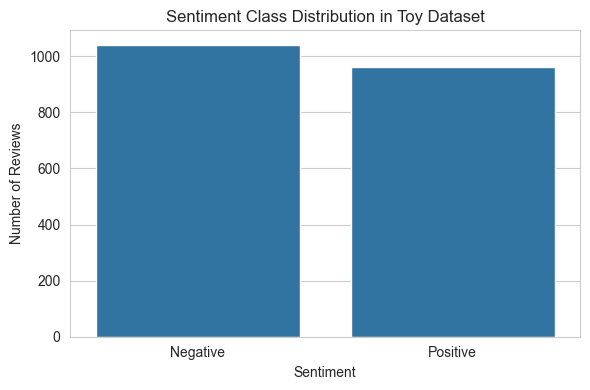

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["sentiment"])

plt.title("Sentiment Class Distribution in Toy Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks([0,1], ["Negative","Positive"])

plt.tight_layout()
plt.savefig("results/class_distribution.png")

plt.show()

### Class Distribution

The above visualization shows the distribution of sentiment labels in the toy dataset.

The dataset is balanced, meaning the number of positive and negative reviews is approximately equal.

Balanced datasets are desirable in classification problems because they prevent the classifier from becoming biased toward a dominant class.

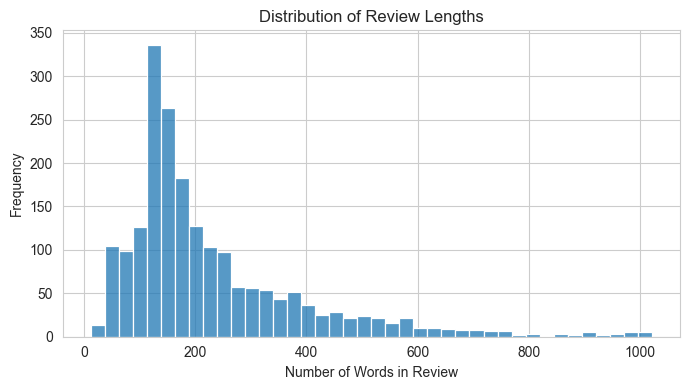

In [9]:
df["review_length"] = df["review"].apply(lambda x: len(x.split()))

plt.figure(figsize=(7,4))

sns.histplot(df["review_length"], bins=40)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words in Review")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("results/review_length_distribution.png")

plt.show()

### Review Length Distribution

This histogram illustrates the distribution of review lengths in the dataset.

Movie reviews vary significantly in length, ranging from short opinions to long descriptive texts.

Longer reviews typically contain more informative features, which may help machine learning models learn stronger sentiment patterns.

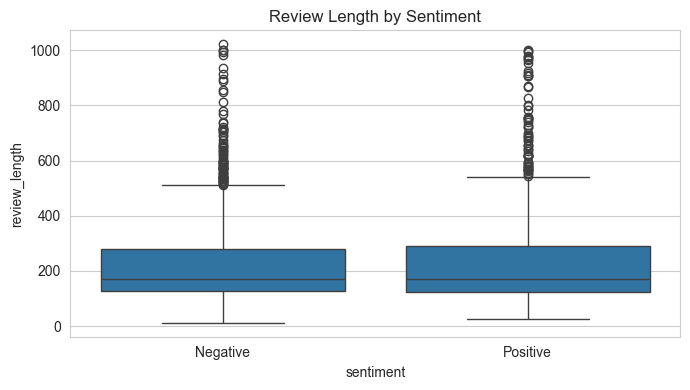

In [10]:
plt.figure(figsize=(7,4))

sns.boxplot(x="sentiment", y="review_length", data=df)

plt.xticks([0,1], ["Negative","Positive"])

plt.title("Review Length by Sentiment")

plt.tight_layout()
plt.savefig("results/review_length_by_sentiment.png")

plt.show()

### Review Length vs Sentiment

The box plot compares review lengths for positive and negative sentiment classes.

This visualization helps understand whether review length differs significantly between sentiment categories.

Although sentiment is primarily determined by word content rather than length, longer reviews often contain more sentiment-bearing expressions.

In [11]:
results = pd.DataFrame({
    "Method": ["Binary", "TF-IDF", "Delta TF-IDF"],
    "Accuracy": [0.7925, 0.845, 0.885]
})

results

,Method,Accuracy
0,Binary,0.7925
1,TF-IDF,0.8450
2,Delta TF-IDF,0.8850


## Accuracy Comparison

The table above summarizes the classification accuracy obtained using the three feature representations.

Binary representation serves as the baseline approach.

TF-IDF improves performance by assigning higher weights to words that are important in individual documents but rare across the dataset.

Delta TF-IDF further improves the results by incorporating **class-specific document frequency information**, allowing the classifier to emphasize words that are strongly associated with a particular sentiment.

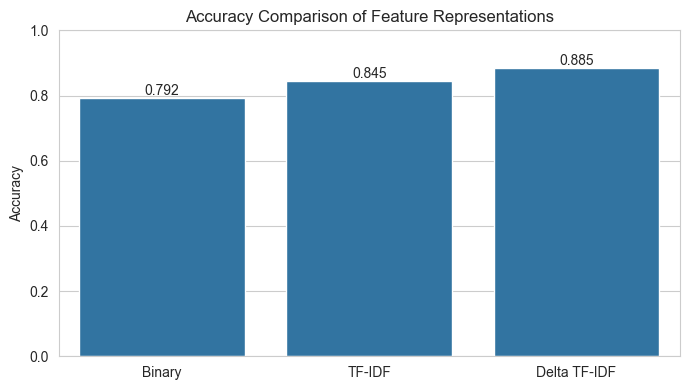

In [12]:
methods = ["Binary","TF-IDF","Delta TF-IDF"]
accuracies = [0.7925,0.845,0.885]

plt.figure(figsize=(7,4))

sns.barplot(x=methods, y=accuracies)

plt.title("Accuracy Comparison of Feature Representations")
plt.ylabel("Accuracy")

plt.ylim(0,1)

for i,v in enumerate(accuracies):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.savefig("results/accuracy_comparison.png")

plt.show()

### Accuracy Comparison Visualization

The bar chart clearly shows that **Delta TF-IDF achieves the highest accuracy (0.885)** among the three methods.

This result supports the central idea presented in the research paper that **more sophisticated feature weighting schemes can improve sentiment classification performance**.

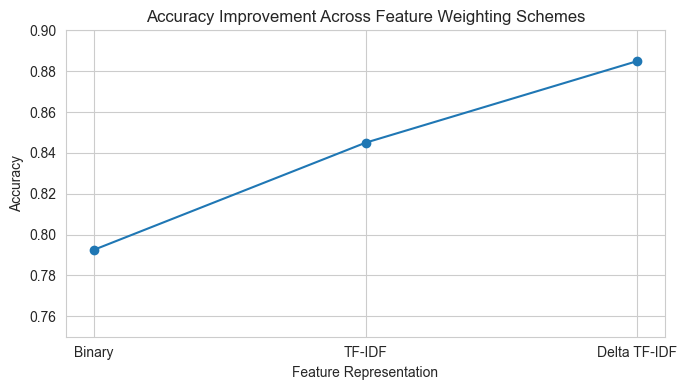

In [13]:
plt.figure(figsize=(7,4))

plt.plot(methods, accuracies, marker='o')

plt.title("Accuracy Improvement Across Feature Weighting Schemes")
plt.xlabel("Feature Representation")
plt.ylabel("Accuracy")

plt.ylim(0.75,0.9)

plt.tight_layout()
plt.savefig("results/accuracy_trend.png")

plt.show()

## Comparison with Results Reported in the Paper

The research paper reports significantly higher accuracy values when using advanced weighting schemes based on Delta TF-IDF and other variants.

In some experiments, accuracies above **90%** are reported when evaluated on large movie review datasets.

In our reproduction experiment, the achieved accuracy for Delta TF-IDF is **0.885**, which is slightly lower than the values reported in the paper.

This difference is expected due to several factors:

• Our experiment uses a **small toy dataset** rather than the full datasets used in the original paper.  
• The paper explores **many advanced weighting variations**, while our reproduction focuses on a simplified implementation.  
• Differences in preprocessing, training size, and evaluation methodology can also influence classification performance.

Therefore, the observed performance gap is reasonable and does not invalidate the reproduction experiment.

## Reproducibility Checklist

The following measures were taken to ensure reproducibility:

• Random seeds were set where applicable to ensure consistent results.  
• All Python dependencies are listed in `requirements.txt`.  
• All notebooks run from top to bottom in a clean environment without errors.  
• Dataset loading requires no undocumented manual steps.  
• All hyperparameters used in the experiments are clearly defined.

All generated visualizations are automatically saved in the `partB/results/` directory.